In [1]:
import os
os.chdir("../")
print(os.getcwd())

d:\git\ServerAnomalyDetection


In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from evaluation.splitter import time_split
from preprocessing.feature_engineer import build_model_input

df = pd.read_parquet("data/processed/server_metrics_20260503_20260504.parquet")
df = build_model_input(df)
train, test = time_split(df, 0.7)

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(train), index=train.index, columns=train.columns)
X_test = pd.DataFrame(scaler.transform(test), index=test.index, columns=test.columns)


In [3]:
X_train.describe().round(2)

,mspt_5s_avg,mspt_5s_min,mspt_5s_max,mspt_10s_avg,mspt_10s_min,mspt_10s_max,mspt_1m_avg,mspt_1m_min,mspt_1m_max,heap_used_mb,non_heap_used_mb,cpu_process_pct,thread_count,gc_count_rate,gc_time_rate_ms
count,1852.00,1852.00,1852.00,1852.00,1852.00,1852.00,1852.00,1852.00,1852.00,1852.00,1852.00,1852.00,1852.00,1852.00,1852.00
mean,-0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-3.18,-3.67,-0.54,-3.24,-3.78,-0.43,-3.55,-3.87,-0.29,-1.62,-4.67,-0.30,-6.71,-0.46,-0.43
25%,-0.59,-0.68,-0.18,-0.61,-0.75,-0.18,-0.61,-0.90,-0.17,-0.75,-0.58,-0.30,0.21,-0.46,-0.43
50%,0.12,0.16,-0.08,0.11,0.14,-0.07,0.11,0.22,-0.13,-0.11,0.01,-0.30,0.21,-0.46,-0.43
75%,0.66,0.63,0.07,0.66,0.65,0.04,0.73,0.65,-0.07,0.57,0.93,-0.30,0.21,-0.46,-0.43
max,9.84,7.32,40.41,10.72,5.20,29.08,3.42,1.92,12.11,3.34,2.51,24.26,4.36,4.90,12.43


In [4]:
X_test.describe().round(2)

,mspt_5s_avg,mspt_5s_min,mspt_5s_max,mspt_10s_avg,mspt_10s_min,mspt_10s_max,mspt_1m_avg,mspt_1m_min,mspt_1m_max,heap_used_mb,non_heap_used_mb,cpu_process_pct,thread_count,gc_count_rate,gc_time_rate_ms
count,795.00,795.00,795.00,795.00,795.00,795.00,795.00,795.00,795.00,795.00,795.00,795.00,795.00,795.00,795.00
mean,-0.52,-1.02,-0.05,-0.53,-1.09,-0.03,-0.61,-1.27,-0.01,0.28,1.55,0.16,0.21,-0.24,-0.14
std,1.87,1.67,0.91,1.89,1.69,0.90,2.01,1.66,0.84,0.96,0.08,0.87,0.00,0.69,1.89
min,-3.18,-3.67,-0.54,-3.24,-3.78,-0.48,-3.64,-3.87,-0.38,-1.45,1.25,-0.30,0.21,-0.46,-0.43
25%,-1.84,-1.99,-0.34,-1.89,-2.14,-0.32,-2.04,-2.17,-0.20,-0.52,1.55,-0.30,0.21,-0.46,-0.43
50%,-0.04,-0.20,-0.07,0.03,-0.24,-0.05,0.02,-1.47,-0.10,0.21,1.58,-0.30,0.21,-0.46,-0.43
75%,1.06,0.28,0.14,1.06,0.27,0.10,1.09,0.22,-0.03,1.02,1.59,0.44,0.21,-0.46,-0.43
max,4.98,3.14,23.62,3.22,3.30,16.95,2.97,0.93,6.99,2.49,1.67,5.37,0.21,3.56,42.89


In [5]:
import torch

torch.manual_seed(42)

X_train_t = torch.tensor(X_train.to_numpy(), dtype=torch.float32)
X_test_t = torch.tensor(X_test.to_numpy(), dtype=torch.float32)

dataset = torch.utils.data.TensorDataset(X_train_t)
data_loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

In [6]:
len(data_loader)

29

In [7]:
next(iter(data_loader))[0].shape

torch.Size([64, 15])

In [8]:
next(iter(data_loader))[0].dtype

torch.float32

In [9]:
import torch.nn as nn

dense_ae = nn.Sequential(
    nn.Linear(in_features=15, out_features=8),
    nn.ReLU(),
    nn.Linear(in_features=8, out_features=4),
    nn.ReLU(),
    nn.Linear(in_features=4, out_features=8),
    nn.ReLU(),
    nn.Linear(in_features=8, out_features=15)
)

print(dense_ae)

Sequential(
  (0): Linear(in_features=15, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=4, bias=True)
  (3): ReLU()
  (4): Linear(in_features=4, out_features=8, bias=True)
  (5): ReLU()
  (6): Linear(in_features=8, out_features=15, bias=True)
)


In [10]:
output = dense_ae(next(iter(data_loader))[0])
output.shape

torch.Size([64, 15])

In [11]:
params = dense_ae.parameters()
print(sum(p.numel() for p in params))

339


In [12]:
optimizer = torch.optim.Adam(dense_ae.parameters(), lr=0.001)
loss_fn = nn.MSELoss()
loss_history = []

for epoch in range(100):
    total_loss = 0
    for batch in data_loader:
        output = dense_ae(batch[0])
        loss = loss_fn(output, batch[0])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    loss_history.append(total_loss / len(data_loader))

print(loss_history)

[1.0471372357730209, 1.0252945793086086, 0.9946945474065584, 0.9439058057193098, 0.8712137742289181, 0.7844627365983766, 0.7064672883214622, 0.6591027286545984, 0.6370744499666937, 0.6251583582368391, 0.619809805319227, 0.6161239147186279, 0.601586920434031, 0.5914757816955961, 0.5817450588119442, 0.5720915326784397, 0.5622878424052534, 0.5527418605212507, 0.5428507281788464, 0.5312883992647303, 0.5197269844597784, 0.5095347962502775, 0.4998689016391491, 0.49452793187108535, 0.48064704650434953, 0.4724359101262586, 0.46805186929373904, 0.45468282853734904, 0.44382587126616774, 0.433903928460746, 0.42299858814683455, 0.4130263467287195, 0.40120168801011713, 0.3923136370963064, 0.38402501211084167, 0.3738815224376218, 0.36951305999838074, 0.3581364720032133, 0.35239908664390956, 0.3460217585851406, 0.33980791579032765, 0.3354109988130372, 0.33068044997494794, 0.3243371808323367, 0.3171580284833908, 0.3100541228878087, 0.3029573991380889, 0.2949476961431832, 0.2860323031400812, 0.27818666

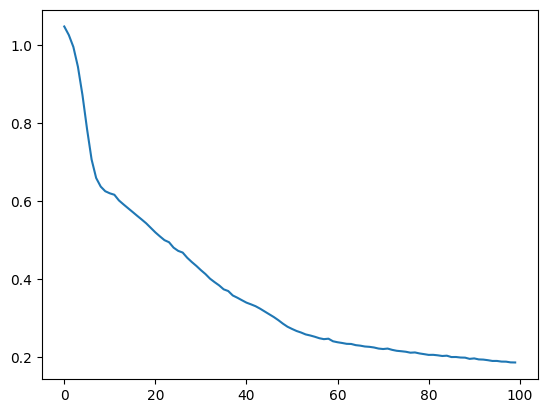

In [13]:
import matplotlib.pyplot as plt

plt.plot(loss_history)

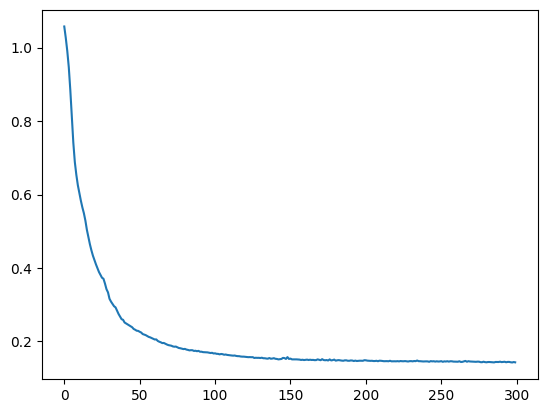

In [14]:
import torch.nn as nn

torch.manual_seed(42)
dense_ae = nn.Sequential(
    nn.Linear(in_features=15, out_features=8),
    nn.ReLU(),
    nn.Linear(in_features=8, out_features=4),
    nn.ReLU(),
    nn.Linear(in_features=4, out_features=8),
    nn.ReLU(),
    nn.Linear(in_features=8, out_features=15)
)

optimizer = torch.optim.Adam(dense_ae.parameters(), lr=0.001)
loss_fn = nn.MSELoss()
loss_history = []

for epoch in range(300):
    total_loss = 0
    for batch in data_loader:
        output = dense_ae(batch[0])
        loss = loss_fn(output, batch[0])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    loss_history.append(total_loss / len(data_loader))

import matplotlib.pyplot as plt

plt.plot(loss_history)

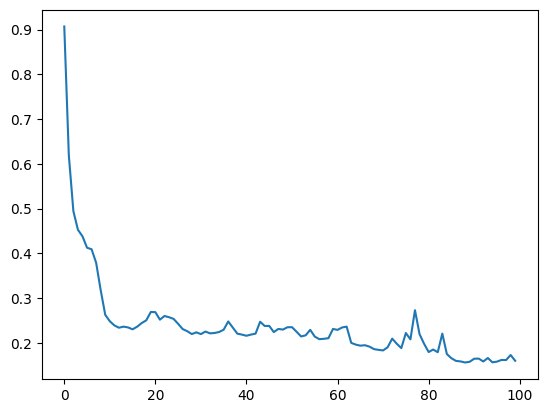

In [15]:
import torch.nn as nn

torch.manual_seed(42)
dense_ae = nn.Sequential(
    nn.Linear(in_features=15, out_features=8),
    nn.ReLU(),
    nn.Linear(in_features=8, out_features=4),
    nn.ReLU(),
    nn.Linear(in_features=4, out_features=8),
    nn.ReLU(),
    nn.Linear(in_features=8, out_features=15)
)

optimizer = torch.optim.Adam(dense_ae.parameters(), lr=0.01)
loss_fn = nn.MSELoss()
loss_history = []

for epoch in range(100):
    total_loss = 0
    for batch in data_loader:
        output = dense_ae(batch[0])
        loss = loss_fn(output, batch[0])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    loss_history.append(total_loss / len(data_loader))

import matplotlib.pyplot as plt

plt.plot(loss_history)

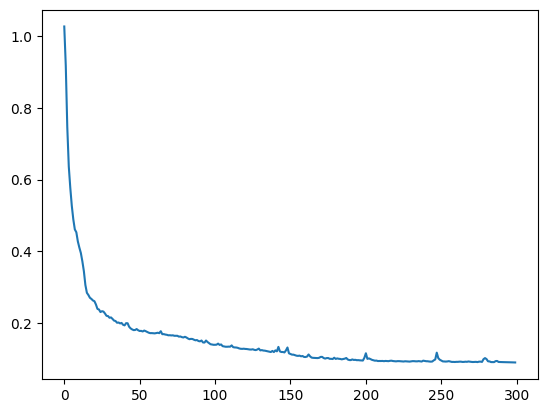

In [16]:
import torch.nn as nn

torch.manual_seed(42)
dense_ae = nn.Sequential(
    nn.Linear(in_features=15, out_features=8),
    nn.ReLU(),
    nn.Linear(in_features=8, out_features=4),
    nn.ReLU(),
    nn.Linear(in_features=4, out_features=8),
    nn.ReLU(),
    nn.Linear(in_features=8, out_features=15)
)

optimizer = torch.optim.Adam(dense_ae.parameters(), lr=0.003)
loss_fn = nn.MSELoss()
loss_history = []

for epoch in range(300):
    total_loss = 0
    for batch in data_loader:
        output = dense_ae(batch[0])
        loss = loss_fn(output, batch[0])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    loss_history.append(total_loss / len(data_loader))

import matplotlib.pyplot as plt

plt.plot(loss_history)

In [30]:
dense_ae.eval()
with torch.no_grad():
    o_train = dense_ae(X_train_t)
    m_train = ((o_train - X_train_t) ** 2).mean(dim=1).numpy()
    s_train = pd.Series(m_train, index=X_train.index, name="ae_anomaly_score")

    o_test = dense_ae(X_test_t)
    m_test = ((o_test - X_test_t) ** 2).mean(dim=1).numpy()
    s_test = pd.Series(m_test, index=X_test.index, name="ae_anomaly_score")

    th = s_train.quantile(0.99)
    summary = pd.DataFrame({
        "train": s_train.describe(percentiles=[.5, .9, .99]),
        "test": s_test.describe(percentiles=[.5, .9, .99]),
    })
    summary.loc[f"rate>{th}"] = [(s_train > th).mean(), (s_test > th).mean()]

summary

,train,test
count,1852.000000,795.000000
mean,0.090867,0.460669
std,0.151926,2.469970
min,0.004451,0.007747
50%,0.047414,0.225199
90%,0.193413,0.692529
99%,0.692472,2.218843
max,2.697423,65.832825
rate>0.6924724751710892,0.010259,0.100629


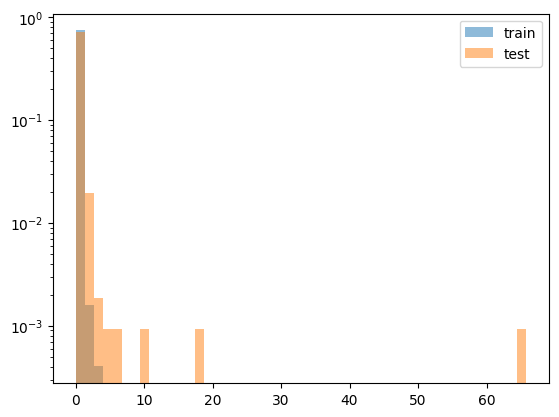

In [31]:
import numpy as np

bins = np.linspace(min(s_train.min(), s_test.min()), max(s_train.max(), s_test.max()), 50)
plt.hist(s_train, bins=bins, density=True, alpha=0.5, label="train")
plt.hist(s_test, bins=bins, density=True, alpha=0.5, label="test")
plt.yscale("log")
plt.legend()

In [32]:
s_train.rank(ascending=False).loc["2026-05-03 21:07:11"], s_test.rank(ascending=False).loc["2026-05-03 23:53:31"]

(np.float64(56.0), np.float64(4.0))

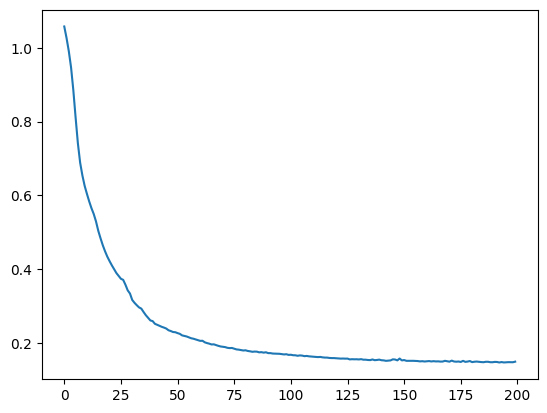

In [33]:
import torch.nn as nn

torch.manual_seed(42)
dense_ae = nn.Sequential(
    nn.Linear(in_features=15, out_features=8),
    nn.ReLU(),
    nn.Linear(in_features=8, out_features=4),
    nn.ReLU(),
    nn.Linear(in_features=4, out_features=8),
    nn.ReLU(),
    nn.Linear(in_features=8, out_features=15)
)

optimizer = torch.optim.Adam(dense_ae.parameters(), lr=0.001)
loss_fn = nn.MSELoss()
loss_history = []

for epoch in range(200):
    total_loss = 0
    for batch in data_loader:
        output = dense_ae(batch[0])
        loss = loss_fn(output, batch[0])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    loss_history.append(total_loss / len(data_loader))

import matplotlib.pyplot as plt

plt.plot(loss_history)

In [34]:
dense_ae.eval()
with torch.no_grad():
    o_train = dense_ae(X_train_t)
    m_train = ((o_train - X_train_t) ** 2).mean(dim=1).numpy()
    s_train = pd.Series(m_train, index=X_train.index, name="ae_anomaly_score")

    o_test = dense_ae(X_test_t)
    m_test = ((o_test - X_test_t) ** 2).mean(dim=1).numpy()
    s_test = pd.Series(m_test, index=X_test.index, name="ae_anomaly_score")

    th = s_train.quantile(0.99)
    summary = pd.DataFrame({
        "train": s_train.describe(percentiles=[.5, .9, .99]),
        "test": s_test.describe(percentiles=[.5, .9, .99]),
    })
    summary.loc[f"rate>{th}"] = [(s_train > th).mean(), (s_test > th).mean()]

summary

,train,test
count,1852.000000,795.000000
mean,0.146632,0.420753
std,0.716560,2.168811
min,0.004928,0.008207
50%,0.045214,0.185614
90%,0.308341,0.689576
99%,1.483441,1.901397
max,27.841713,56.818405
rate>1.4834412133693697,0.010259,0.028931


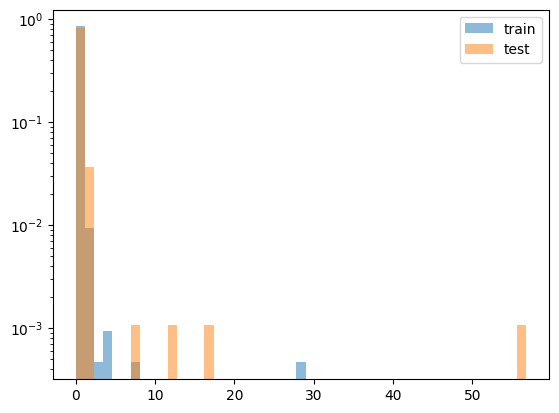

In [35]:
import numpy as np

bins = np.linspace(min(s_train.min(), s_test.min()), max(s_train.max(), s_test.max()), 50)
plt.hist(s_train, bins=bins, density=True, alpha=0.5, label="train")
plt.hist(s_test, bins=bins, density=True, alpha=0.5, label="test")
plt.yscale("log")
plt.legend()

In [36]:
s_train.rank(ascending=False).loc["2026-05-03 21:07:11"], s_test.rank(ascending=False).loc["2026-05-03 23:53:31"]

(np.float64(5.0), np.float64(4.0))